In [1]:
from Functions import utils as u

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:


data = u.extract_data(UMP_threshold=-3.75)

display(data)

features_and_label = ['Teff', 'NUVDered','colorColorY','UMP_flag']
#features_and_label = ['Teff', 'bp_rp_dered', 'colorColorY','UMP_flag'] #add logg once we figure out NaNs

selected_data = data[features_and_label].copy()

#remove all rows where logg is Nan
#selected_data = selected_data.dropna(subset=['logg'])

print(f"Num of UMPs: {len(selected_data[selected_data['UMP_flag']==1])}")


,Survey,FeH,NUVDered,bp_rp_dered,Teff,logg,colorColorY,UMP_flag
0,Bonifacio,-2.83,20.194627,1.003094,6303,4.25,-1.016775,0
1,Lai,-3.00,21.265522,0.737908,4805,1.48,-0.965118,0
2,Lai,-3.50,21.244102,0.775386,4750,1.31,-0.109841,0
3,Lai,-2.90,20.176450,1.003778,5163,2.47,-0.312304,0
4,Lai,-3.95,22.584123,1.754697,4827,1.51,-8.287684,1
...,...,...,...,...,...,...,...,...
485,Yong,-2.60,18.570030,0.582178,6507,NaN,-1.297989,0
486,Yong,-2.65,17.412597,0.570395,6624,NaN,-1.041163,0
487,Yong,-2.60,18.019629,0.580172,6479,NaN,-1.252573,0
488,Yong,-2.68,18.129256,0.664409,6196,NaN,-1.605187,0


Num of UMPs: 22


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def scale_and_split(data, target_column, test_size=0.2, random_state=42):
    """
    Splits the dataset into training and validation sets, and scales the features.

    Parameters:
    - data: pd.DataFrame
    - target_column: str, name of the target column
    - test_size: float, proportion of validation set
    - random_state: int, for reproducibility

    Returns:
    - X_train_scaled, X_val_scaled, y_train, y_val, scaler
    """
    # Separate features and target
    X = data.drop(columns=[target_column]).copy()
    y = data[target_column].copy()

    # Split into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled, y_train, y_val, scaler

x_train, x_val, y_train, y_val, scaler = scale_and_split(selected_data, 'UMP_flag',)



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from sklearn.metrics import precision_score, recall_score, confusion_matrix




def tune_logistic_regression(X_train, X_val, y_train, y_val, C_values=None,threshold=0.85, patience= 5):
    """
    Trains logistic regression models over a range of C values and plots accuracy.

    Parameters:
    - X_train, X_val: scaled feature arrays
    - y_train, y_val: target arrays
    - C_values: list or array of regularization strengths to try

    Returns:
    - best_model: trained LogisticRegression instance with best C
    """
    if C_values is None:
        C_values = np.logspace(-4, 2, 30)

    best_acc = 0
    best_model = None
    wait = 0
    accuracies = []
    models =[]



    for C in C_values:
        #model = LogisticRegression(C=C, solver='liblinear', max_iter=1000,class_weight={0:1,1:25})
        model = LogisticRegression(C=C, solver='liblinear', max_iter=1000,class_weight='balanced')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        accuracies.append(acc)
        models.append(model)
        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        if acc > best_acc:
            best_acc = acc
            best_model = model
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered at C={C:.4f} for regularization tuning.")
                break


    # Plot accuracy vs C
    
    print("Precision:", precision_score(y_valid, y_pred))
    print("Recall:", recall_score(y_valid, y_pred))
    print(confusion_matrix(y_valid, y_pred))

    
    
    plt.figure(figsize=(8, 5))
    plt.semilogx(C_values[:len(accuracies)], accuracies, marker='o')
    plt.xlabel("Regularization Strength (C)")
    plt.ylabel("Validation Accuracy")
    plt.title("Logistic Regression Hyperparameter Tuning")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Best model
    best_idx = np.argmax(accuracies)
    best_model = models[best_idx]
    print(f"Best C: {C_values[best_idx]:.4f} | Accuracy: {accuracies[best_idx]:.4f}")

    # Confusion matrix
    y_pred_best = best_model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix (Best Model)")
    plt.show()

    return best_model



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_recall_curve, 
    precision_score, recall_score, confusion_matrix
)


def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
    """
    Trains a logistic regression classifier optimized for high precision.
    
    Parameters
    ----------
    X_train, y_train : training data (already scaled)
    X_valid, y_valid : validation data (already scaled)
    target_precision : float
        Minimum precision requirement for threshold selection.
    
    Returns
    -------
    best_model : trained LogisticRegression model
    best_threshold : float
        Probability threshold used to convert probabilities to class predictions.
    """

    # -------------------------------------
    # 1. Model + Hyperparameter Search
    # -------------------------------------
    model = LogisticRegression(
        class_weight={0:1,1:50},
        #class_weight='balanced',
        solver='lbfgs',
        max_iter=10000
    )

    param_grid = {'C': np.logspace(-4, 2, 40)}

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='precision',
        cv=5,
        factor=3,
        verbose=1
    )
    
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print(f"\nBest C found: {search.best_params_['C']:.5f}")

    # -------------------------------------
    # 2. Get validation probabilities
    # -------------------------------------
    
    y_proba = best_model.predict_proba(X_valid)[:, 1]

    # -------------------------------------
    # 3. Select Threshold
    # -------------------------------------
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_proba)

    idx = np.where(precisions >= target_precision)[0]
    if len(idx) > 0:
        best_threshold = thresholds[idx[0]-1]
    else:
        best_threshold = 0.5  # fallback if target precision unreachable

    print(f"Selected Threshold = {best_threshold:.3f}")

    y_pred = (y_proba >= best_threshold).astype(int)

    # -------------------------------------
    # 4. Confusion Matrix Plot
    # -------------------------------------
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
    print(f"Recall: {recall_score(y_valid, y_pred):.4f}")

    # -------------------------------------
    # 5. Precision vs Regularization Strength Plot
    # -------------------------------------
    mean_test_scores = search.cv_results_['mean_test_score']
    C_values = search.cv_results_['param_C'].data.astype(float)

    plt.figure(figsize=(7, 5))
    plt.semilogx(C_values, mean_test_scores, marker='o')
    plt.xlabel("Regularization Strength C (log scale)")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs Regularization Strength (C)")
    plt.grid(True)
    plt.show()

    # -------------------------------------
    # 6. Precision–Recall Curve Plot
    # -------------------------------------
    plt.figure(figsize=(7, 5))
    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 20
max_resources_: 392
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 20
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\s

----------
iter: 1
n_candidates: 14
n_resources: 60
Fitting 5 folds for each of 14 candidates, totalling 70 fits
----------
iter: 2
n_candidates: 5
n_resources: 180
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best C found: 34.55107
Selected Threshold = 0.956


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [  nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025 0.025]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan  

<Figure size 500x400 with 0 Axes>

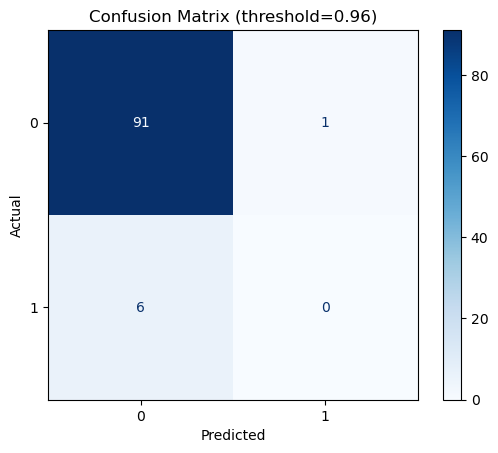

Precision: 0.0000
Recall: 0.0000


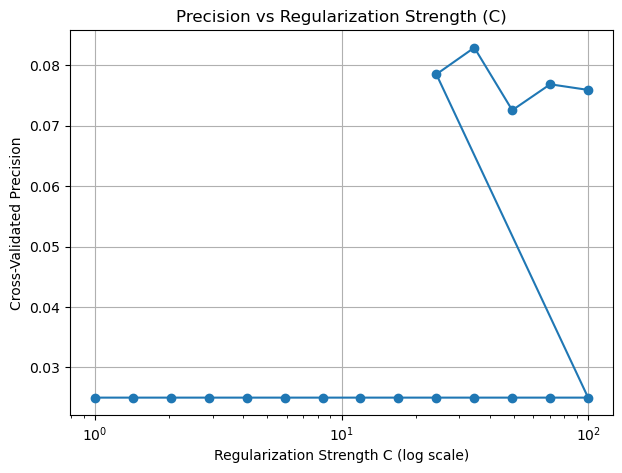

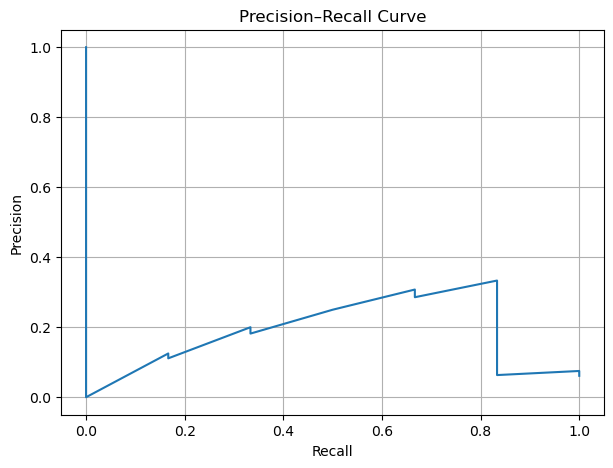

In [6]:
# Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
best_model,best_threshold = UMP_predictor_model(x_train, y_train, x_val, y_val,target_precision=0.70)


In [7]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import numpy as np

y_proba = best_model.predict_proba(x_val)[:,1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print("Precision at 0.5:", precision_score(y_val, y_pred_05, zero_division=0))
print("Recall at 0.5:", recall_score(y_val, y_pred_05, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_05))

print("Positives predicted:", y_pred_05.sum())
print("Proba stats (positives only):", np.percentile(y_proba[y_val==1], [0,25,50,75,100]))
print("Proba stats (negatives):", np.percentile(y_proba[y_val==0], [0,25,50,75,100]))

print()
y_pred_t = (y_proba >= best_threshold).astype(int)

print("Precision at best t:", precision_score(y_val, y_pred_t, zero_division=0))
print("Recall at best t:", recall_score(y_val, y_pred_t, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_t))


# distribution of probabilities

print("Positives predicted:", y_pred_t.sum())
print("Proba stats (positives only):", np.percentile(y_proba[y_val==1], [0,25,50,75,100]))
print("Proba stats (negatives):", np.percentile(y_proba[y_val==0], [0,25,50,75,100]))


Precision at 0.5: 0.07407407407407407
Recall at 0.5: 1.0
Confusion matrix:
 [[17 75]
 [ 0  6]]
Positives predicted: 81
Proba stats (positives only): [0.52672891 0.77799342 0.783704   0.78676367 0.80423676]
Proba stats (negatives): [0.00792132 0.55940768 0.63962417 0.7182387  0.95569291]

Precision at best t: 0.0
Recall at best t: 0.0
Confusion matrix:
 [[91  1]
 [ 6  0]]
Positives predicted: 1
Proba stats (positives only): [0.52672891 0.77799342 0.783704   0.78676367 0.80423676]
Proba stats (negatives): [0.00792132 0.55940768 0.63962417 0.7182387  0.95569291]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer


def UMP_predictor_tree_model(X_train, y_train, X_val, y_val):
    # Define model
    model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    )

    # Grid of hyperparameters to tune
    param_grid = {
        'max_depth': [2, 4, 6, 8, 10, None],
        'min_samples_split': [2, 5, 10, 20]
    }

    # Precision scorer that avoids NaN warnings
    precision_scorer = make_scorer(precision_score, zero_division=0)

    # Halving Grid Search (early stopping style search)
    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=precision_scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    # Fit search
    search.fit(X_train, y_train)

    # Best model found
    best_model = search.best_estimator_

    print("\nBest Hyperparameters:", search.best_params_)

    # Predictions & precision evaluation
    y_pred = best_model.predict(X_val)
    final_precision = precision_score(y_val, y_pred, zero_division=0)
    print("Validation Precision:", final_precision)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best Model)")
    plt.show()

    # --- Precision vs Depth Plot ---
    results = search.cv_results_
    depths = results['param_max_depth']
    mean_precisions = results['mean_test_score']

    plt.figure(figsize=(7, 4))
    plt.plot(depths, mean_precisions, marker='o')
    plt.xlabel("max_depth")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs. Tree Depth")
    plt.grid(True)
    plt.show()

    return best_model


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 20
max_resources_: 392
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 20
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
160 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\linear_model\_logistic.py

----------
iter: 1
n_candidates: 14
n_resources: 60
Fitting 5 folds for each of 14 candidates, totalling 70 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\s

----------
iter: 2
n_candidates: 5
n_resources: 180
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best C found: 5.87802
Selected Threshold = 0.828


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan 0.03666667 0.03666667
 0.03888889 0.03888889 0.03888889 0.03888889 0.03888889 0.03888889
 0.03666667 0.03666667 0.03666667 0.03666667 0.03666667 0.03666667
 0.05574454 0.06087938 0.06021164 0.06030525 0.06030525]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [       nan       

<Figure size 500x400 with 0 Axes>

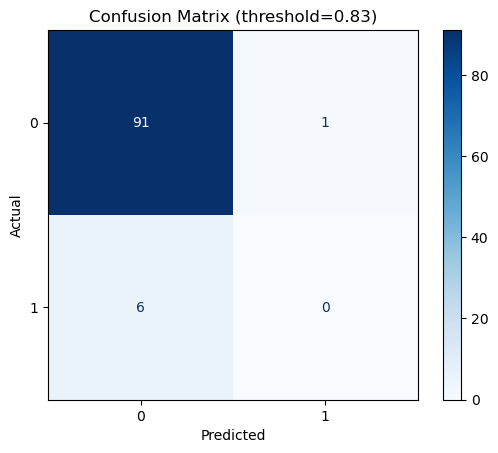

Precision: 0.0000
Recall: 0.0000


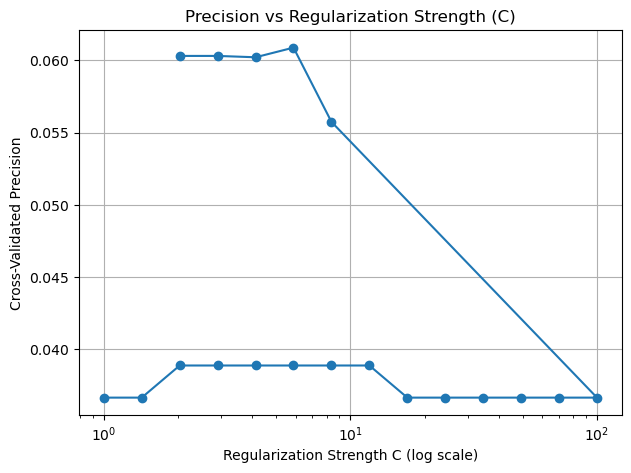

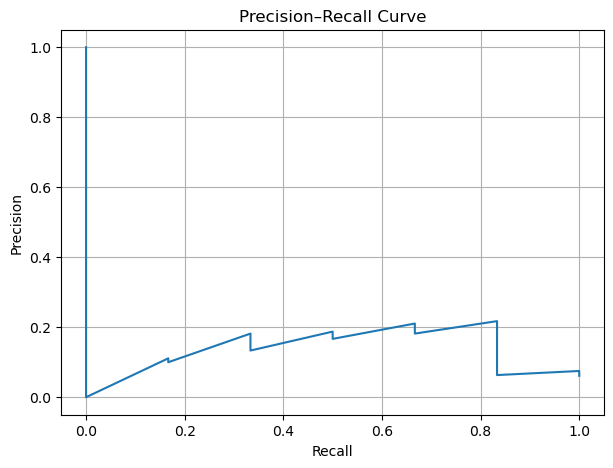

In [9]:
# Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
best_model,best_threshold = UMP_predictor_model(x_train, y_train, x_val, y_val)
